In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [2]:
plt.rcParams['font.family'] = 'AppleGothic'

In [3]:
my_path = os.path.join("data", "jeju_card.csv") # make cross-platform path
jeju_df = pd.read_csv(my_path)

In [4]:
jeju_df.head() 

,시도명,시군구명,지역구분,업종명,이용자 구분,연령대,성별,연월,이용자수,이용횟수,이용금액
0,제주도,제주시,읍면,유흥,제주도민,60대이상,여,2018-12,23,29,4240100
1,제주도,제주시,읍면,유흥,제주도민,60대이상,남,2018-12,114,190,27414000
2,제주도,제주시,읍면,유흥,제주도민,50대,여,2018-12,52,71,6848000
3,제주도,제주시,읍면,유흥,제주도민,50대,남,2018-12,259,458,91468500
4,제주도,제주시,읍면,유흥,제주도민,40대,여,2018-12,77,99,10021600


In [5]:
jeju_df.info() # 11 columns, 19573 rows and non-null for whole rows

<class 'pandas.DataFrame'>
RangeIndex: 19573 entries, 0 to 19572
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   시도명     19573 non-null  str  
 1   시군구명    19573 non-null  str  
 2   지역구분    19573 non-null  str  
 3   업종명     19573 non-null  str  
 4   이용자 구분  19573 non-null  str  
 5   연령대     19573 non-null  str  
 6   성별      19573 non-null  str  
 7   연월      19573 non-null  str  
 8   이용자수    19573 non-null  int64
 9   이용횟수    19573 non-null  int64
 10  이용금액    19573 non-null  int64
dtypes: int64(3), str(8)
memory usage: 2.8 MB


In [6]:
jeju_df.describe(include="all")

,시도명,시군구명,지역구분,업종명,이용자 구분,연령대,성별,연월,이용자수,이용횟수,이용금액
count,19573,19573,19573,19573,19573,19573,19573,19573,19573.000000,19573.000000,1.957300e+04
unique,1,2,2,8,2,7,2,28,NaN,NaN,NaN
top,제주도,제주시,도심,식음료,내국인관광객,50대,남,2017-10,NaN,NaN,NaN
freq,19573,9852,9858,2688,9807,3376,9795,738,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2987.681347,5980.462525,2.100849e+08
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5331.172895,13623.951410,3.921408e+08
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000e+03
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.000000,371.000000,1.765947e+07
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,972.000000,1376.000000,7.142090e+07
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3169.000000,5710.000000,2.169743e+08


In [7]:
object_columns = jeju_df.columns[jeju_df.dtypes == 'object'] 
object_columns

Index([], dtype='str')

In [8]:
for col in object_columns:   # Print unique values for each object column
    print(col)     
    print(jeju_df[col].unique(), '\n')     #The 2016 data is incomplete

In [9]:
jeju_df['연도'] = jeju_df['연월'].str.split('-').str[0] # Make additional year column

In [10]:
jeju_df = jeju_df[jeju_df['연도'] != '2016'] # exract only years from 2017 and 2018

In [11]:
jeju_df.loc[jeju_df["연령대"] == "20 미만", "연령대"] = "20대미만" # Both '20 미만' and '20대미만' mean the same thing, just different formatting

In [12]:
jeju_df['연령대'].unique()

<ArrowStringArray>
['60대이상', '50대', '40대', '30대', '20대미만', '20대']
Length: 6, dtype: str

In [13]:
#-------------------------------------Data exploration and preprocessing complete-------------------------------------------

In [14]:
groupby_ym = jeju_df.groupby('연월').sum(numeric_only=True).reset_index() #group by "연월"(year, month) and reset index for furher graphing
groupby_ym

,연월,이용자수,이용횟수,이용금액
0,2017-01,2044697,3962878,158062633602
1,2017-02,1937989,3686906,142673272629
2,2017-03,2139087,4265024,158170622304
3,2017-04,2261037,4428571,164145266282
4,2017-05,2422539,4744952,174450463090
5,2017-06,2328383,4606602,166023890619
6,2017-07,2520117,5048178,177270011408
7,2017-08,2634037,5212389,178853518885
8,2017-09,2374142,4765159,168355520204
9,2017-10,2270758,4453613,164810287642


<Axes: xlabel='연월', ylabel='이용금액'>

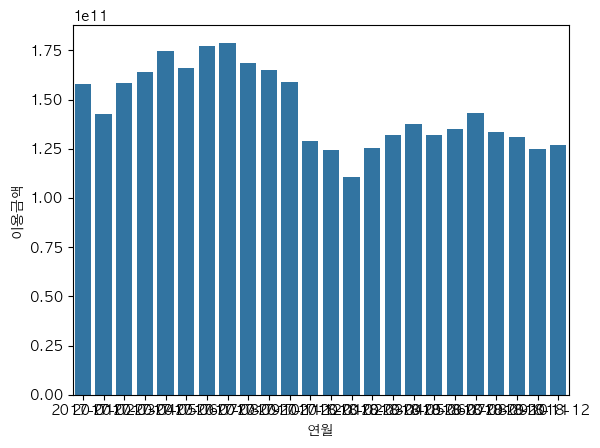

In [15]:
sns.barplot(data=groupby_ym, x='연월', y='이용금액') # It's hard to read itself

In [16]:
plt.rcParams['figure.figsize'] = (10, 5) # Expand graph by 10(horizontal), 5(vertical)

Text(0, 0.5, 'Spending (100M KRW)')

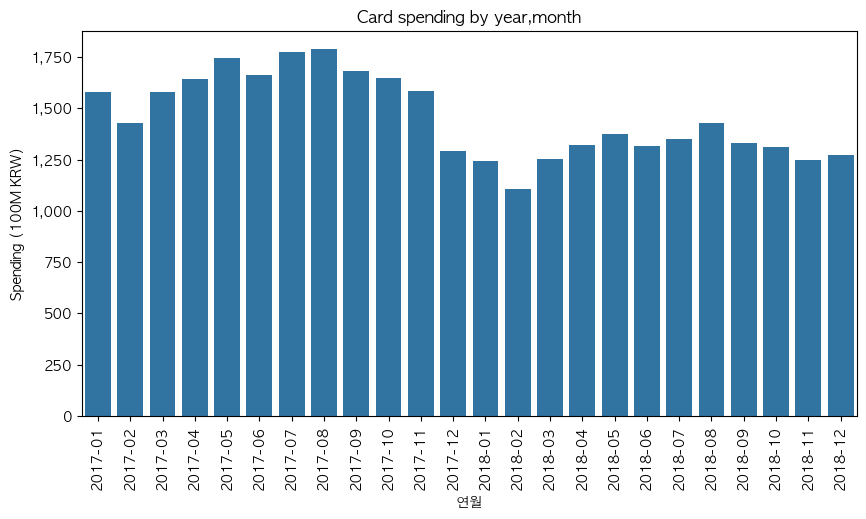

In [17]:
sns.barplot(data=groupby_ym, x='연월', y='이용금액')
plt.xticks(rotation=90)
plt.title('Card spending by year,month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}')) #Format y-axis labels in units of 100 million (억)
plt.ylabel('Spending (100M KRW)')

In [18]:
# As it gets closer to winter, spending decreases. Also, comparing 2017 and 2018, overall spending declined in 2018

In [19]:
groupby_ym_age = jeju_df.groupby(['연도', '연령대']).sum(numeric_only=True).reset_index()
groupby_ym_age #group by year, ages

,연도,연령대,이용자수,이용횟수,이용금액
0,2017,20대,4800559,9304114,208175160124
1,2017,20대미만,203078,429896,4996657612
2,2017,30대,7080363,13499213,437721213544
3,2017,40대,6965143,14414930,561248406540
4,2017,50대,5158034,10314259,468286978356
5,2017,60대이상,2640430,5069478,260136246561
6,2018,20대,4262563,8714136,175770246392
7,2018,20대미만,216056,475236,5027234286
8,2018,30대,5759053,11372820,320955678476
9,2018,40대,6081331,12925032,442123304148


Text(0, 0.5, 'Spending (100M KRW)')

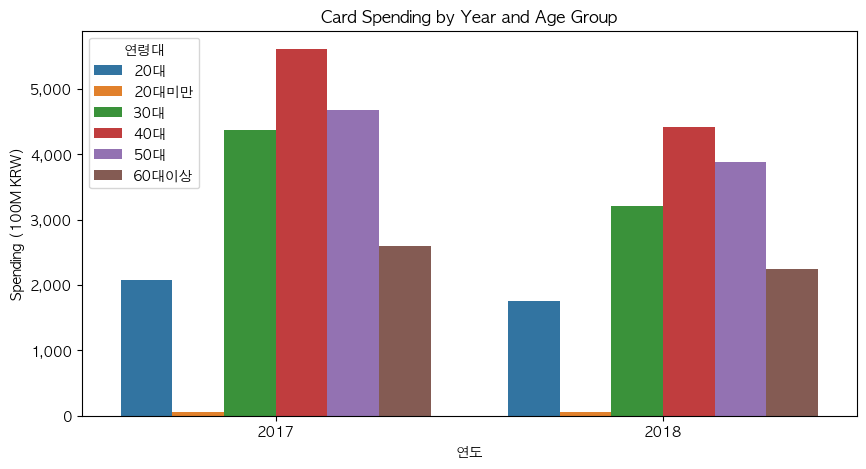

In [20]:
sns.barplot(data=groupby_ym_age, x='연도', y='이용금액', hue='연령대')
plt.title('Card Spending by Year and Age Group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')

In [21]:
# Age groups are not in order

In [22]:
jeju_df['연령대'] = pd.Categorical(jeju_df['연령대'],
                                      categories=['20대미만', '20대', '30대', '40대', '50대', '60대이상'],
                                      ordered=True) # Use category funciton to order age

Text(0, 0.5, 'Spending (100M KRW)')

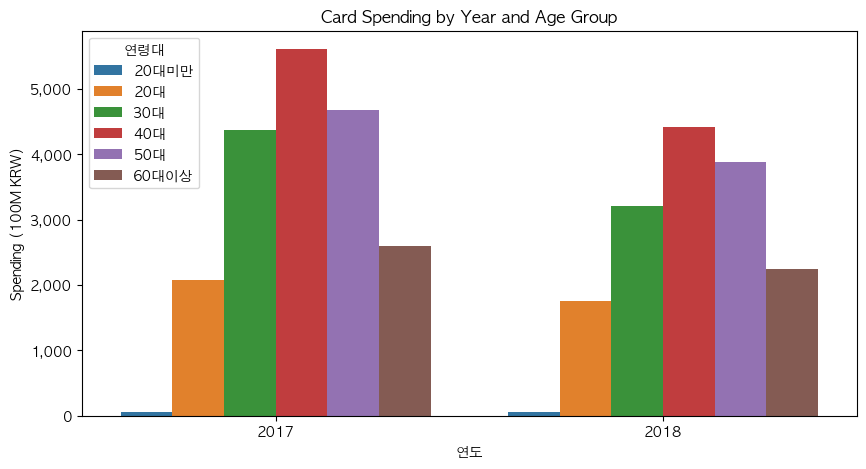

In [23]:
groupby_ym_age = jeju_df.groupby(['연도', '연령대']).sum(numeric_only=True).reset_index()

sns.barplot(data=groupby_ym_age, x='연도', y='이용금액', hue='연령대')
plt.title('Card Spending by Year and Age Group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')

In [24]:
# Overall spending declined regardless of age group

In [25]:
groupby_ym_user = jeju_df.groupby(['연도', '이용자 구분']).sum(numeric_only=True).reset_index() # group by year and user type wheter Residents or Tourists
groupby_ym_user

,연도,이용자 구분,이용자수,이용횟수,이용금액
0,2017,내국인관광객,12761026,20113119,754434825907
1,2017,제주도민,14086581,32918771,1186129836830
2,2018,내국인관광객,11179654,17830178,633357078211
3,2018,제주도민,12241253,30011987,922893881613


Text(0, 0.5, 'Spending (100M KRW)')

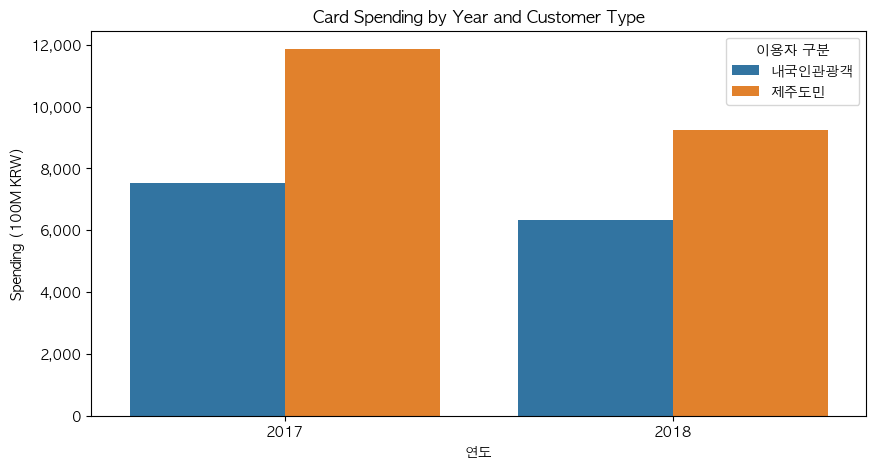

In [26]:
sns.barplot(data=groupby_ym_user, x='연도', y='이용금액', hue='이용자 구분')
plt.title('Card Spending by Year and Customer Type')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')


In [27]:
#Both tourists and residents showed an overall decline in spending

Text(0, 0.5, 'Spending (100M KRW)')

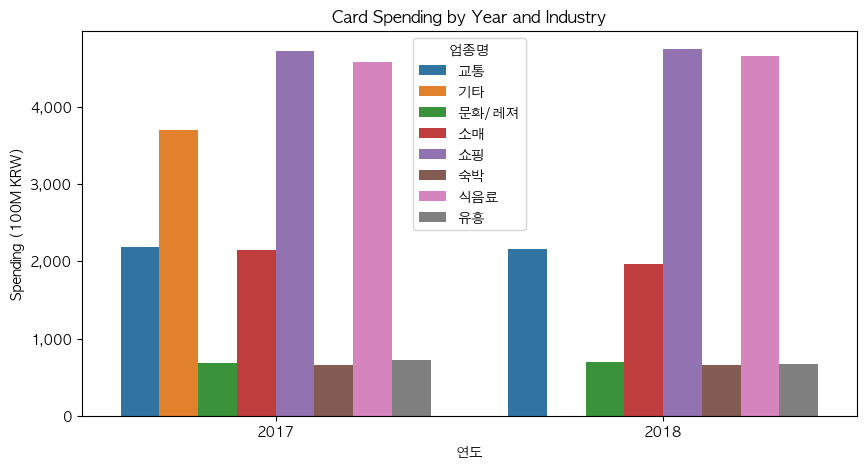

In [28]:
groupby_ym_market = jeju_df.groupby(['연도', '업종명']).sum(numeric_only=True).reset_index()

sns.barplot(data=groupby_ym_market, x='연도', y='이용금액', hue='업종명')
plt.title('Card Spending by Year and Industry')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')

In [29]:
# The orange bar for '기타' disappeared

In [30]:
jeju_df[jeju_df['업종명'] == '기타']

,시도명,시군구명,지역구분,업종명,이용자 구분,연령대,성별,연월,이용자수,이용횟수,이용금액,연도
8820,제주도,제주시,읍면,기타,제주도민,60대이상,여,2017-11,515,1087,68991695,2017
8821,제주도,제주시,읍면,기타,제주도민,60대이상,남,2017-11,1320,2902,248832140,2017
8822,제주도,제주시,읍면,기타,제주도민,50대,여,2017-11,825,1586,105991421,2017
8823,제주도,제주시,읍면,기타,제주도민,50대,남,2017-11,1623,3314,344444658,2017
8824,제주도,제주시,읍면,기타,제주도민,40대,여,2017-11,1064,1955,197205323,2017
...,...,...,...,...,...,...,...,...,...,...,...,...
16682,제주도,서귀포시,도심,기타,내국인관광객,30대,여,2017-01,1126,1661,61983110,2017
16683,제주도,서귀포시,도심,기타,내국인관광객,30대,남,2017-01,1289,1902,54641270,2017
16684,제주도,서귀포시,도심,기타,내국인관광객,20대,여,2017-01,795,1060,29265651,2017
16685,제주도,서귀포시,도심,기타,내국인관광객,20대,남,2017-01,719,987,19987700,2017


In [31]:
jeju_df[jeju_df['업종명'] == '기타']['연월'].unique()  # '기타' seems to be missing in 2018

<ArrowStringArray>
['2017-11', '2017-10', '2017-09', '2017-08', '2017-07', '2017-06', '2017-05',
 '2017-04', '2017-03', '2017-02', '2017-01']
Length: 11, dtype: str

In [32]:
jeju_df = jeju_df[jeju_df['업종명'] != '기타'] # Get rid of '기타'

Text(0, 0.5, 'Spending (100M KRW)')

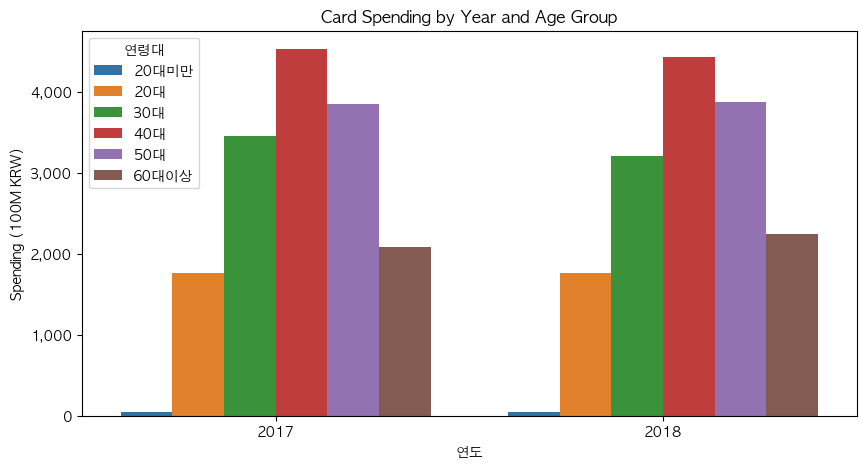

In [33]:
groupby_ym_age = jeju_df.groupby(['연도', '연령대']).sum(numeric_only=True).reset_index()

sns.barplot(data=groupby_ym_age, x='연도', y='이용금액', hue='연령대')
plt.title('Card Spending by Year and Age Group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')


Text(0, 0.5, 'Spending (100M KRW)')

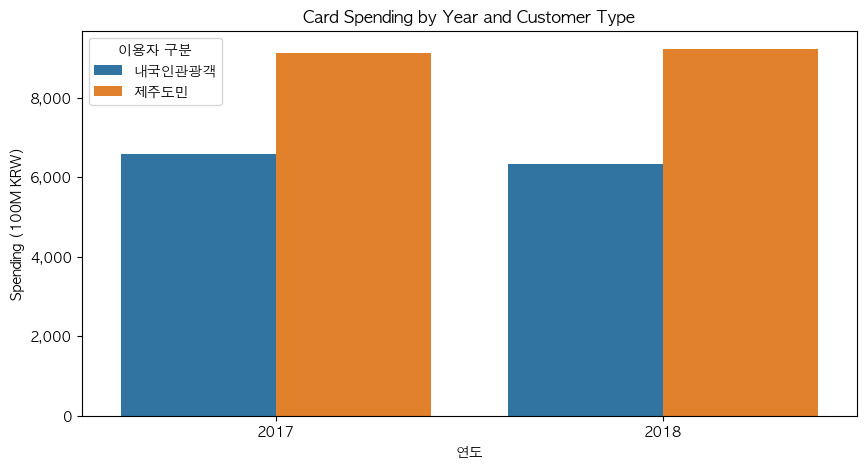

In [34]:
groupby_ym_user = jeju_df.groupby(['연도', '이용자 구분']).sum(numeric_only=True).reset_index()

sns.barplot(data=groupby_ym_user, x='연도', y='이용금액', hue='이용자 구분')
plt.title('Card Spending by Year and Customer Type')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')

Text(0, 0.5, 'Spending (100M KRW)')

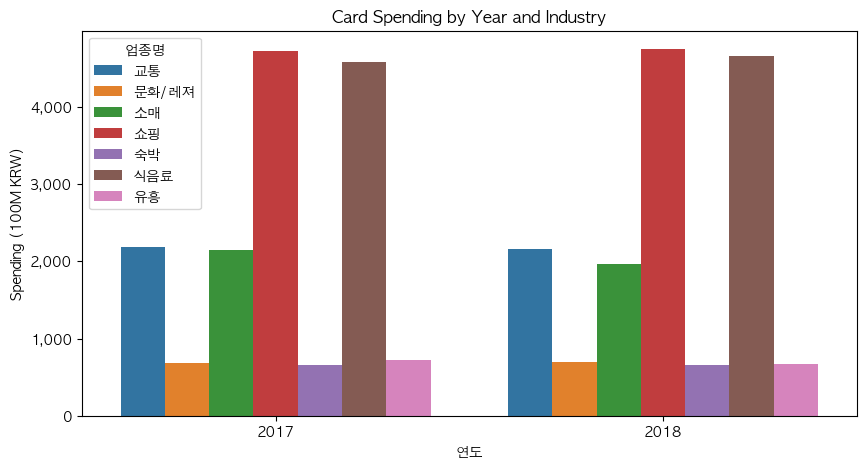

In [35]:
groupby_ym_market = jeju_df.groupby(['연도', '업종명']).sum(numeric_only=True).reset_index()

sns.barplot(data=groupby_ym_market, x='연도', y='이용금액', hue='업종명')
plt.title('Card Spending by Year and Industry')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')


In [36]:
# Excluding '기타', there is little to no difference

In [37]:
# ----------------------------------------Monthly card spending comparison complete----------

In [38]:
groupby_age = jeju_df.groupby('연령대').sum(numeric_only=True).reset_index() # groupby age and get sum for all numeric type
groupby_age

,연령대,이용자수,이용횟수,이용금액
0,20대미만,401769,879205,9478228519
1,20대,8609569,17330083,352340324557
2,30대,11943645,23231348,665648456005
3,40대,12151108,25588896,894568725640
4,50대,9141502,18600897,771684016455
5,60대이상,4683296,9062038,433293299324


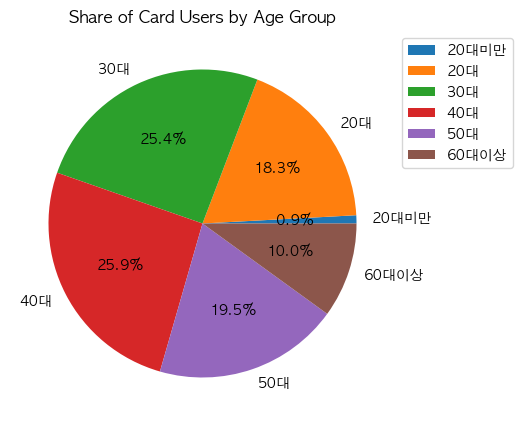

In [39]:
groupby_age.plot(kind='pie', y='이용자수', labels=groupby_age['연령대'],autopct='%.1f%%') # autopct - add percentage
plt.title('Share of Card Users by Age Group')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # move legend to upper right so it can be observed easily

In [40]:
#The 20s to 40s age group accounts for the largest share of card usage

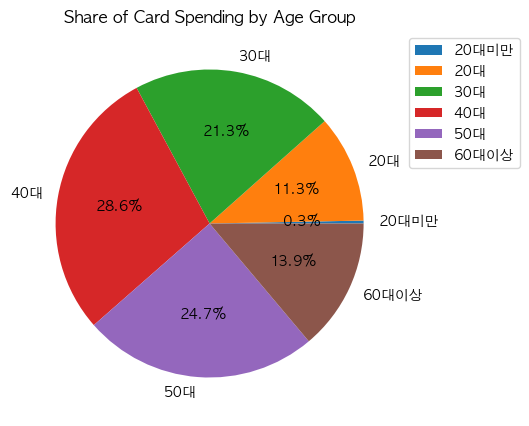

In [41]:
groupby_age.plot(kind='pie', y='이용금액', labels=groupby_age['연령대'], autopct='%.1f%%')
plt.title('Share of Card Spending by Age Group')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [42]:
#People in their 40s show the highest card spending

In [43]:
groupby_age['인당이용금액'] = groupby_age['이용금액'] / groupby_age['이용자수'] # Creating spending per person
groupby_age

,연령대,이용자수,이용횟수,이용금액,인당이용금액
0,20대미만,401769,879205,9478228519,23591.239043
1,20대,8609569,17330083,352340324557,40924.269793
2,30대,11943645,23231348,665648456005,55732.438130
3,40대,12151108,25588896,894568725640,73620.341918
4,50대,9141502,18600897,771684016455,84415.451252
5,60대이상,4683296,9062038,433293299324,92518.879721


Text(0.5, 1.0, 'Card Spending per Person by Age Group')

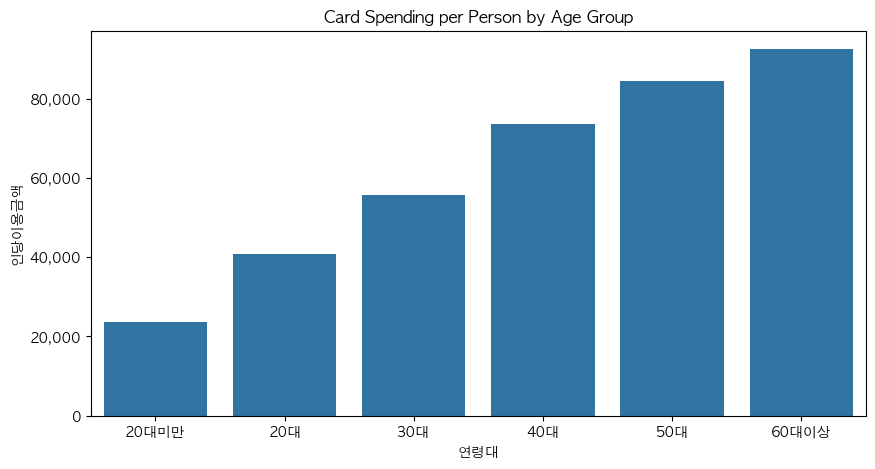

In [44]:
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) # format y-axis
sns.barplot(data=groupby_age, x='연령대', y='인당이용금액')
plt.title('Card Spending per Person by Age Group')

In [45]:
#Spending per person increases as age group gets older

In [46]:
groupby_age_market = jeju_df.groupby(['연령대', '업종명']).sum(numeric_only=True).reset_index() # Group by age group and industry
groupby_age_market.head()

,연령대,업종명,이용자수,이용횟수,이용금액
0,20대미만,교통,3740,4705,285316774
1,20대미만,문화/레져,40499,80073,805245645
2,20대미만,소매,56257,77825,1638514065
3,20대미만,쇼핑,164635,453747,3008788954
4,20대미만,숙박,3681,4953,114390996


Text(0, 0.5, 'Spending (100M KRW)')

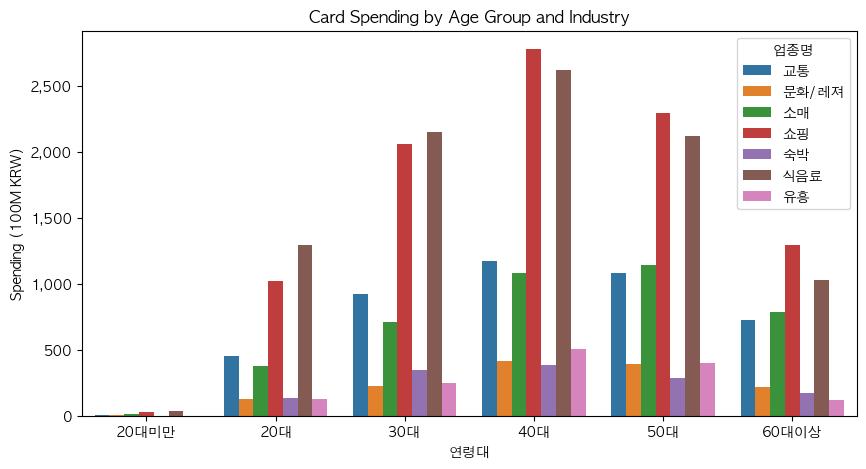

In [47]:
sns.barplot(data=groupby_age_market, x='연령대', y='이용금액', hue='업종명')
plt.title('Card Spending by Age Group and Industry')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
plt.ylabel('Spending (100M KRW)')

In [48]:
#Overall, shopping and food & beverage account for the largest share

Text(0.5, 1.0, 'Card Spending per Person by Age Group and Industry')

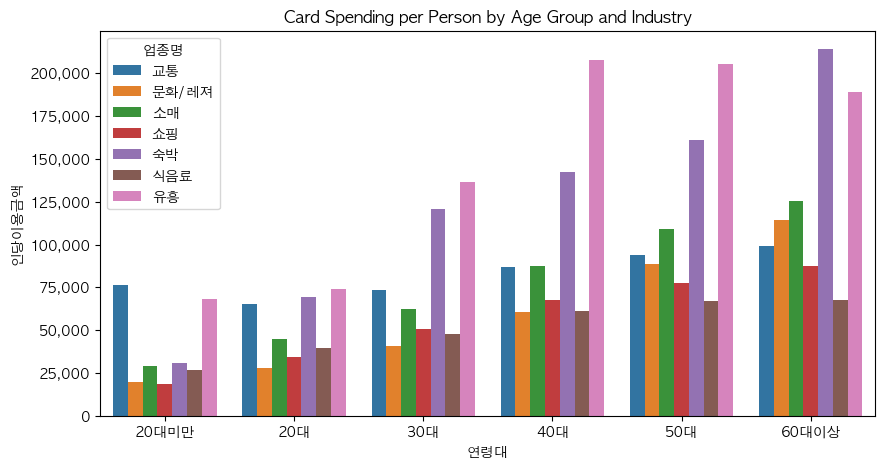

In [49]:
groupby_age_market['인당이용금액'] = groupby_age_market['이용금액'] / groupby_age_market['이용자수'] #Creating spending per person column

sns.barplot(data=groupby_age_market, x='연령대', y='인당이용금액', hue='업종명')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Card Spending per Person by Age Group and Industry')


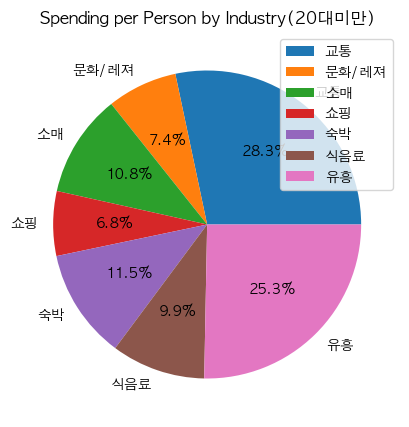

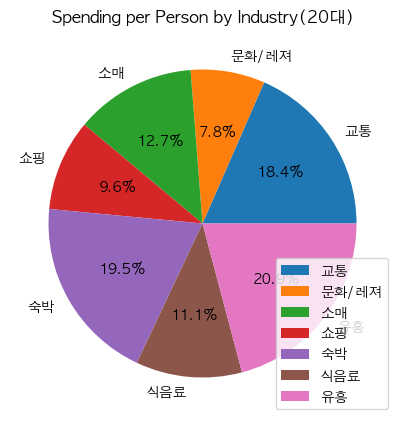

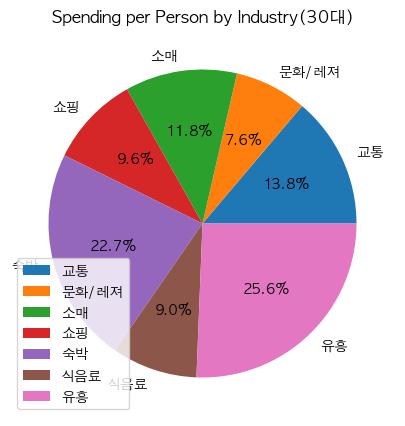

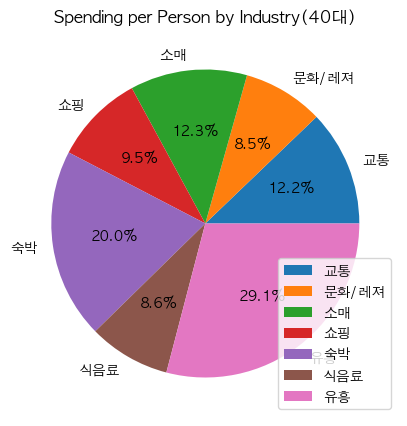

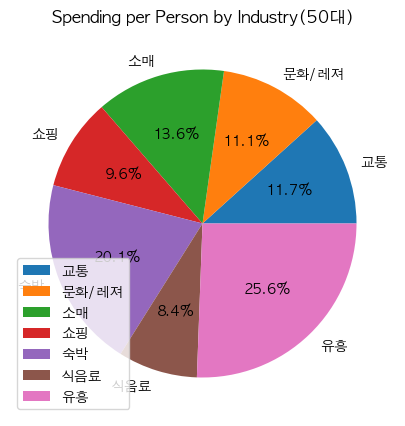

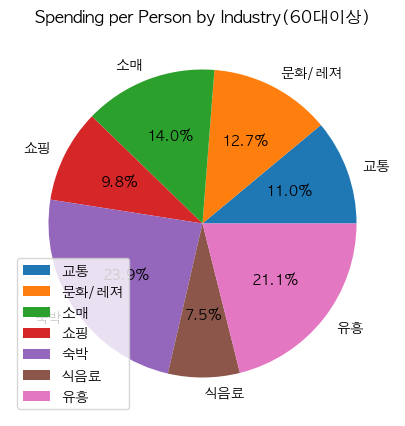

In [50]:
for age in groupby_age_market['연령대'].unique():
    data = groupby_age_market[groupby_age_market['연령대'] == age]
    data.plot(y='인당이용금액', labels=data['업종명'], kind='pie', autopct='%.1f%%')
    plt.title(f'Spending per Person by Industry({age})')
    plt.xticks(rotation=90)
    plt.show() #Create a graph for each age group

<Axes: xlabel='연령대', ylabel='이용금액'>

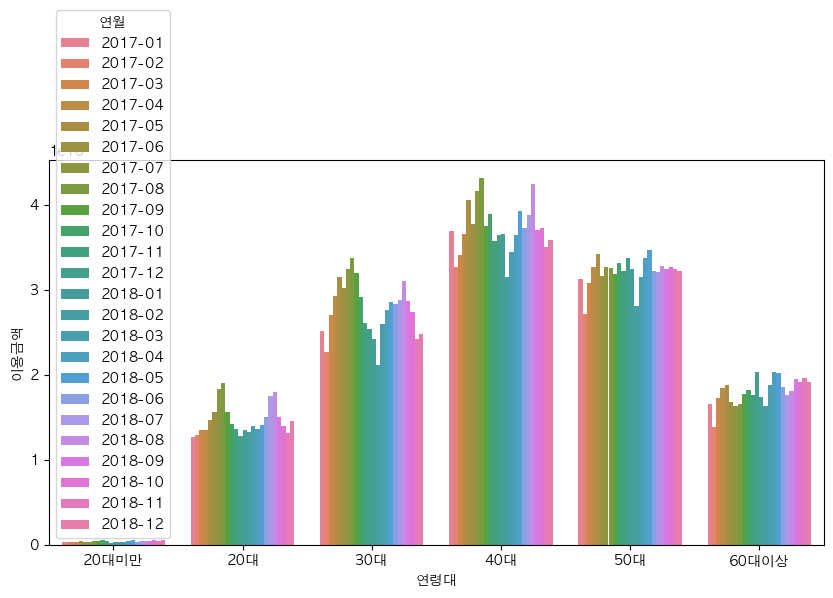

In [51]:
groupby_age_ym = jeju_df.groupby(['연령대', '연월']).sum(numeric_only=True).reset_index()
sns.barplot(data=groupby_age_ym, x='연령대', y='이용금액', hue='연월') #Group by age group and (year,month), then sum all numeric columns

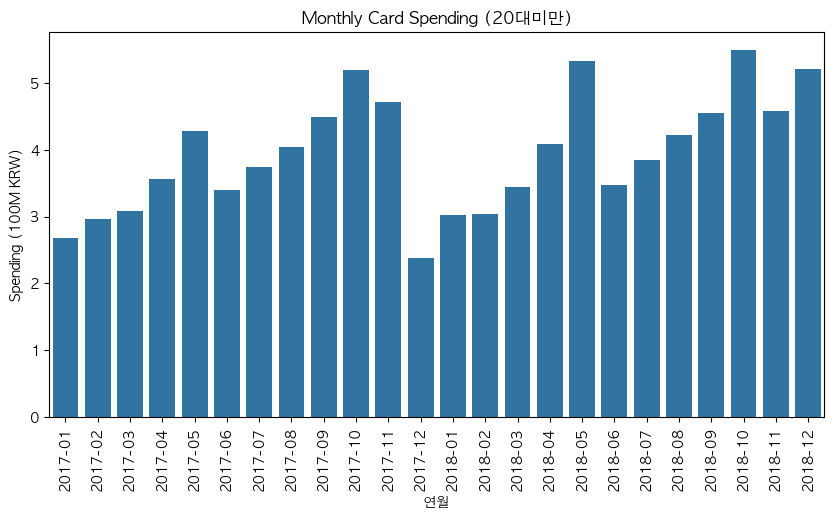

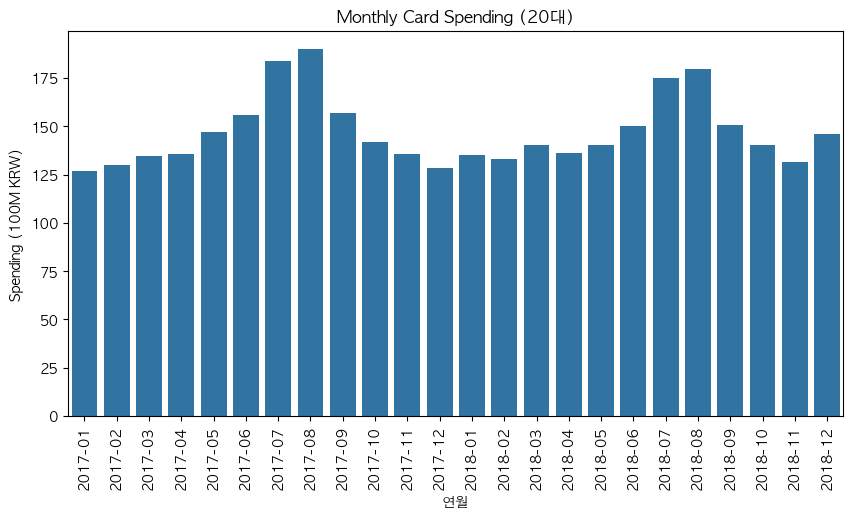

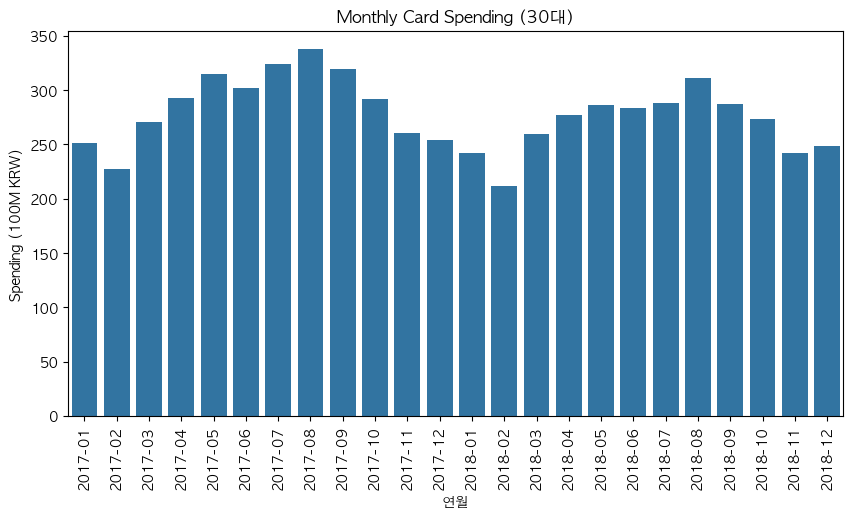

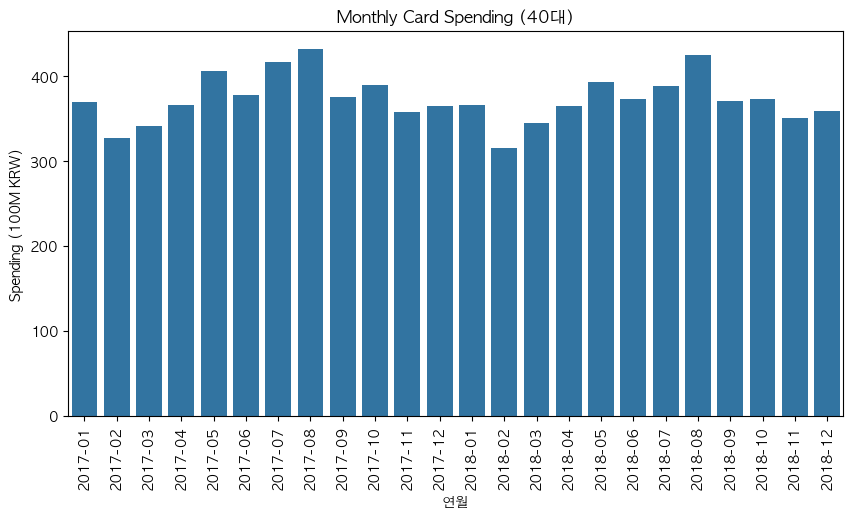

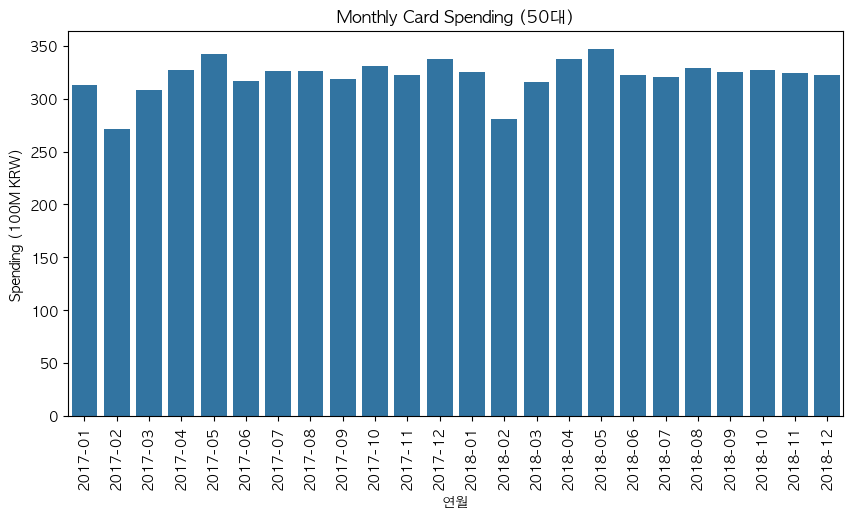

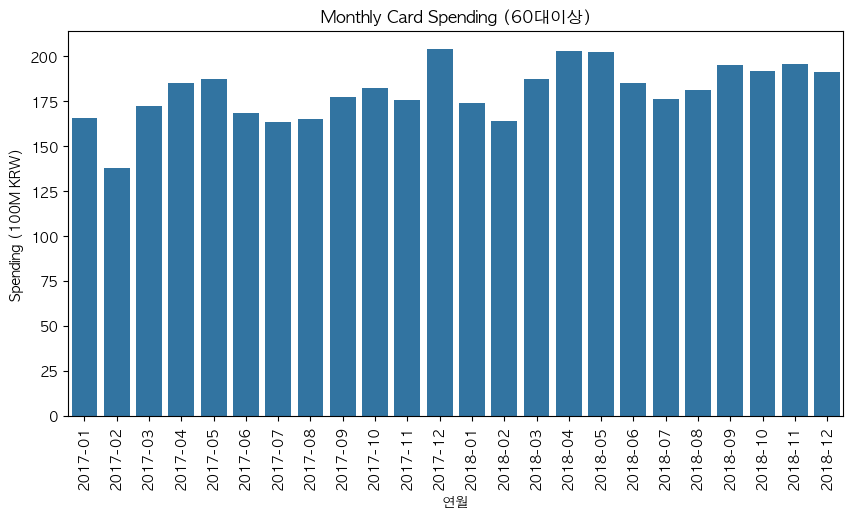

In [52]:
for age in groupby_age_ym['연령대'].unique():
    data = groupby_age_ym[groupby_age_ym['연령대'] == age]
    sns.barplot(data=data, x='연월', y='이용금액')
    plt.title(f'Monthly Card Spending ({age})')
    plt.xticks(rotation=90)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100000000:,.0f}'))
    plt.ylabel('Spending (100M KRW)')
    plt.show() #Visualizing yearly, monthly card spending by age group 

In [53]:
# Most spending is concentrated in July and August

In [54]:
# ----------Conclusion---------------------

## Key Findings & Business Insights

### 1. Seasonal Pattern
- Spending is concentrated in July and August across all age groups
- Spending decreases as winter approaches
- **Recommendation: Plan promotions and staffing around peak summer months**

### 2. Age Group
- 20s–40s account for the largest share of card users
- Spending per person increases with age — 40s show the highest spending
- **Recommendation: Target 30s–40s as the core customer segment**

### 3. Industry
- Shopping and food & beverage account for the largest share overall
- Little difference across age groups excluding '기타'
- **Recommendation: Café fits well within the food & beverage trend in Jeju**

### 4. Residents vs. Tourists
- Both tourists and residents showed an overall decline in spending in 2018
- **Recommendation: Monitor this trend before finalizing location investment**

## Conclusion
Based on card spending data from 2017–2018, the best strategy for a café franchise entering Jeju is to **target the 30s–40s age group**, **open during or before the summer season**, and **focus on tourist-heavy areas** given the high seasonal concentration.